In [176]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from word2number import w2n

Loading the raw CRMLS export. Haven't cleaned anything yet, just want to see what I'm working with.

In [177]:
df = pd.read_csv(r"C:\Users\kikoh\Desktop\IDXExchange\CRMLSSold202502.csv")

Checking `PropertyType` and `PropertySubType` value counts before filtering, want to make sure I filter on the right strings and not miss variants.

In [178]:
# For determining if a regex pattern needed in case of data entry/spelling variations
# df.columns
# df["PropertyType"].value_counts()
# df["PropertySubType"].value_counts()

Narrowing down to single family residential only. Also dropping columns that are agent contact info or otherwise not useful for a price model, no reason to carry those through.

In [179]:
# Filtering for correct fields/categories
housing = df[(df["PropertyType"] == "Residential") & (df["PropertySubType"] == "SingleFamilyResidence")]

# Exclude not useful columns
not_useful_columns = ["StateOrProvince","ListAgentEmail","ListAgentEmail", "ListAgentFirstName", "ListAgentLastName", "CoListAgentFirstName", 
"CoListAgentLastName", "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId", "CoBuyerAgentFirstName","UnparsedAddress","PostalCode", "AboveGradeFinishedArea", "BelowGradeFinishedArea"]
housing = housing.drop(not_useful_columns, axis="columns")

Quick sanity check plot. List price and close price should be almost perfectly correlated, so this is mostly to confirm the data isn't broken before I go further.

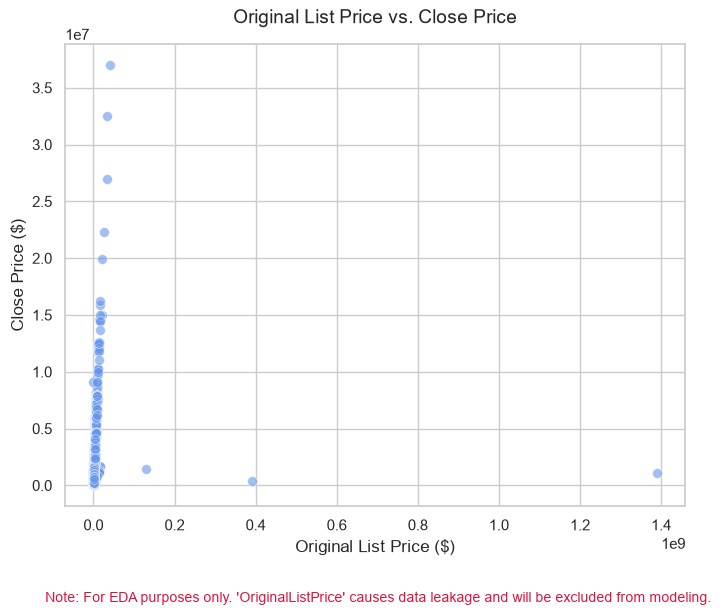

In [180]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

price_scatter = sns.scatterplot(
    data=housing, 
    x="OriginalListPrice", 
    y="ClosePrice",
    alpha=0.6,
    color="cornflowerblue",
    edgecolor="white",
    s=50
)

price_scatter.set_title("Original List Price vs. Close Price", fontsize=14, pad=15)
price_scatter.set_xlabel("Original List Price ($)", fontsize=12)
price_scatter.set_ylabel("Close Price ($)", fontsize=12)

plt.figtext(0.1, -0.05, 
            "Note: For EDA purposes only. 'OriginalListPrice' causes data leakage and will be excluded from modeling.", 
            wrap=True, horizontalalignment='left', fontsize=10, color='crimson')

plt.show()

plt.show()

Now checking if HOA fee has any visible relationship with close price. Not expecting much, curious more than anything.

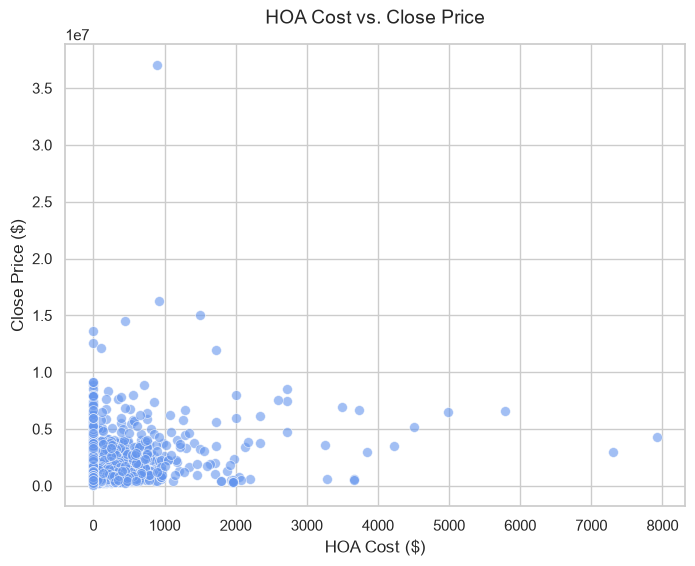

In [181]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

hoa_scatter = sns.scatterplot(
    data=housing, 
    x="AssociationFee", 
    y="ClosePrice",
    alpha=0.6,
    color="cornflowerblue",
    edgecolor="white",
    s=50
)

hoa_scatter.set_title("HOA Cost vs. Close Price", fontsize=14, pad=15)
hoa_scatter.set_xlabel("HOA Cost ($)", fontsize=12)
hoa_scatter.set_ylabel("Close Price ($)", fontsize=12)

plt.show()

This is where it got annoying. The `Levels` column has a mix of numbers, words like "Three", and modifiers like "3ormore". Hardcoding a mapping felt fragile so I pulled in word2number to handle the word cases generally. Also wrote a boolean parser since I noticed the Yes/No amenity columns are actually stored as strings, not real booleans.

In [182]:
amenities_bool_cols = ["ViewYN", "WaterfrontYN", "BasementYN", "PoolPrivateYN", "NewConstructionYN", "AttachedGarageYN"]
amenities_count_cols = ["BedroomsTotal", "BathroomsTotalInteger", "FireplacesTotal", "GarageSpaces", "ParkingTotal", "MainLevelBedrooms", "Stories", "Levels"]
target_cols = amenities_bool_cols + amenities_count_cols

# Handle word values in "Levels" column; Informed me to get word2number because hard-coding wouldn't be generalizable

def general_numeric_parser(val):
    # 1. Handle baseline missing/null values safely
    if pd.isna(val) or val == '':
        return 0
    
    val_str = str(val).strip()
    
    # 2. Split comma-separated inputs to process each token separately
    parts = [p.strip() for p in val_str.split(',')]
    found_numbers = []
    
    for part in parts:
        # Lowercase for standardized text matching
        part_clean = part.lower()
        
        # Test A: Check if it's a known english word string (e.g., "three")
        try:
            # Strip trailing modifiers like "ormore" to help word conversion
            clean_word = part_clean.replace("ormore", "").replace("plus", "").strip()
            num = w2n.word_to_num(clean_word)
            found_numbers.append(num)
            continue
        except ValueError:
            pass # Keep moving if it is not a pure word string
            
        # Test B: Fallback to Regex digit extraction (e.g., handles "2", "3+", "4-car")
        digits = re.findall(r'\d+', part_clean)
        if digits:
            # Take the first sequence of digits found in this segment
            found_numbers.append(int(digits[0]))
            continue
            
    # 3. If any numbers were discovered, return the maximum value found
    if found_numbers:
        return max(found_numbers)
        
    # 4. Ultimate fallback if the string is purely non-numeric (e.g., "MultiSplit")
    return 0

def general_boolean_parser(val):
    if pd.isna(val):
        return 0
        
    # Standardize string tokens
    val_clean = str(val).strip().lower()
    
    # Comprehensive, standard truth map
    truth_values = {'true', 't', 'yes', 'y', '1', '1.0'}
    false_values = {'false', 'f', 'no', 'n', '0', '0.0'}
    
    if val_clean in truth_values:
        return 1
    if val_clean in false_values:
        return 0
        
    # General fallback: If it's a non-empty string not matching false rules, 
    # it usually means a value is present (e.g., "Pool" instead of "True")
    return 0 



In [183]:
# Verification
# housing[amenities_bool_cols].nunique()

Applying both parsers now. First real run failed because of the word values in Levels, that's what pushed me to write general_numeric_parser instead of a hardcoded dict. Filling remaining NaNs with 0 since missing here should mean "doesn't have it" rather than unknown.

In [184]:
# Initial failure due to string/words in Levels column, resolved by generic_numeric_parser
# Fill all NaN values with 0/False across your target columns



# Apply dynamically across any messy text-count column
housing["Levels"] = housing["Levels"].apply(general_numeric_parser)




# Apply dynamically across all your boolean columns; A result of realizing the boolean values were actually string in all caps TRUE or FALSE
for col in amenities_bool_cols:
    housing[col] = housing[col].apply(general_boolean_parser)


housing[target_cols] = housing[target_cols].fillna(0)

for col in amenities_count_cols:
    housing[col] = housing[col].astype(int)


Normalize the count columns so bedrooms/bathrooms/etc are on the same 0-1 scale, then build a rough composite "amenity density" score just to see if there's a visible pattern. This heatmap is more exploratory than final, mainly checking if sorting by total score produces a clean gradient or if it's noisy.

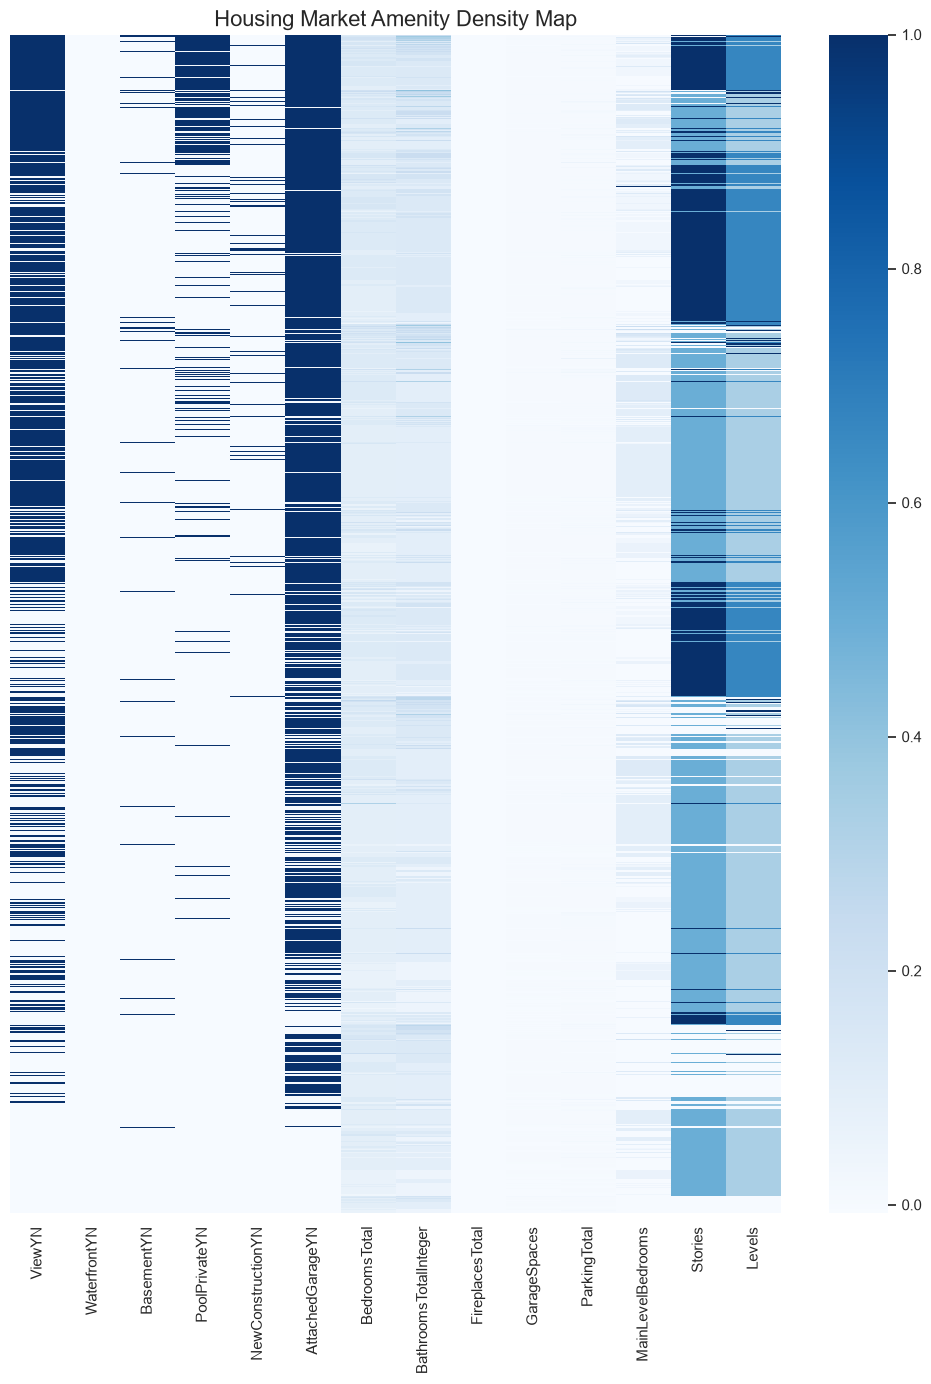

In [185]:
# Normalize the count columns to a 0.0 - 1.0 range, Considered using normalizer but just coded myself
housing_normalized = housing.copy()
for col in amenities_count_cols:
    max_val = housing_normalized[col].max()
    if max_val > 0:
        housing_normalized[col] = housing_normalized[col] / max_val

# Sort houses by total asset density to create a clean waterfall gradient
housing_normalized['Total_Score'] = housing_normalized[target_cols].sum(axis=1)
housing_sorted = housing_normalized.sort_values(by='Total_Score', ascending=False)

# Drop the helper sorting column and plot
plot_data = housing_sorted[target_cols].astype(float)

plt.figure(figsize=(10, 14)) # Tall and narrow for thousands of rows
# 'yticklabels=False' shrinks the rows to pixel level and hides house IDs
sns.heatmap(plot_data, cmap="Blues", yticklabels=False, cbar=True)
plt.title("Housing Market Amenity Density Map", fontsize=16)
plt.tight_layout()
plt.savefig("market_density_report.png", dpi=300) # Crisp 300 DPI for print/PDF
plt.show()